In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(
    "allnames_clean.csv", usecols=["name", "sex", "X1906", "X1956", "X2006"]
)
dff = df[df["sex"] == "F"].copy().drop(columns=["sex"])
dfm = df[df["sex"] == "M"].copy().drop(columns=["sex"])

dff["name"] = dff["name"].apply(lambda s: s[-1])
assert len(dff["name"].unique()) == 26
dfm["name"] = dfm["name"].apply(lambda s: s[-1])
assert len(dfm["name"].unique()) == 26

In [ ]:
dffagg = dff.groupby("name").agg("sum")
dffagg = dffagg / dffagg.sum(axis=0)

dfmagg = dfm.groupby("name").agg("sum")
dfmagg = dfmagg / dfmagg.sum(axis=0)

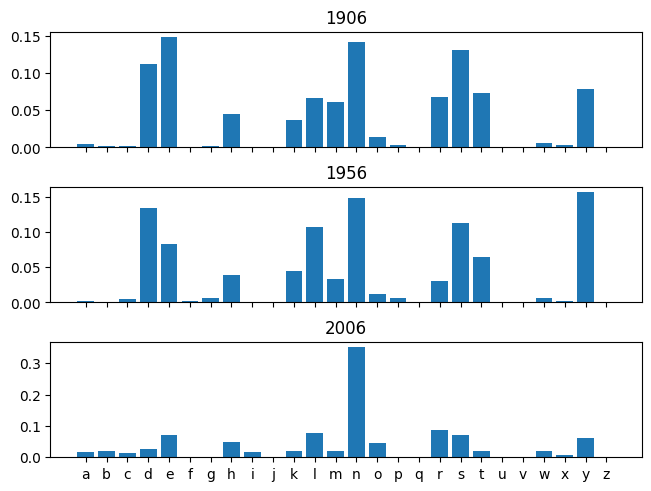

In [42]:
fig, axes = plt.subplots(nrows=3, ncols=1, sharex=True, layout="constrained")
axes[0].bar(dfmagg.index, dfmagg["X1906"])
axes[0].set_title("1906")
axes[1].bar(dfmagg.index, dfmagg["X1956"])
axes[1].set_title("1956")
axes[2].bar(dfmagg.index, dfmagg["X2006"])
axes[2].set_title("2006")
plt.show()